In [221]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [222]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [223]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [224]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [225]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal
       # raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2 – completed
      
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            neighbour = (row + dr, col + dc)
            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions
    

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row = state[0]
        column = state [1]

        dr, dc = MOVES[action]
        return (row + dr, column + dc)
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        #raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1
        # Return 1.
        

In [226]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [227]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [228]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""

    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)  # obstacle
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)  # start
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)  # goal
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)  # path
            else:
                fill = (0.95, 0.95, 0.95)  # free space

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )

            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

for row in range(height):
    for col in range(width):
        state = (row, col)

        if arr[row, col] == 1:
            fill = (0.15, 0.15, 0.15)
        elif start is not None and state == start:
            fill = (0.95, 0.20, 0.20)
        elif goal is not None and state == goal:
            fill = (0.20, 0.70, 0.25)
        elif state in path_set:
            fill = (0.95, 0.90, 0.35)
        else:
            fill = (0.95, 0.95, 0.95)

        rect = patches.Rectangle(
            (col, row),
            1,
            1,
            linewidth=1,
            edgecolor=(0.75, 0.75, 0.75),
            facecolor=fill,
        )

        ax.add_patch(rect)

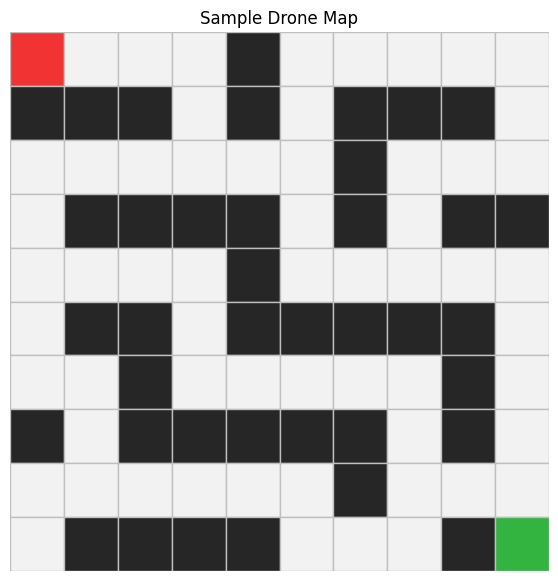

In [229]:
plot_path(sample_grid, start, goal, title = "Sample Drone Map")

In [230]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        # for each action in problem.ACTIONS(s):
        #for each action in problem.actions(s):
        #child = node(state= s_prime, parent=node, action=action, path_cost=cost)
       # yield child
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [231]:

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(state=problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(algorithm, 'success', node, 0, 1, 1)
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While frontier is not empty:
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            


            for child in self.expand(problem, node):
                
               
                    if problem.is_goal(child.state):
                        return SearchResult(algorithm, 'success', child, len(reached), len(frontier), len(reached))
                        
                    if child.state not in reached:    
                        reached.add(child.state)
                        frontier.append(child)
                     

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm, 'failure', None, nodes_expanded, max_frontier_size, len(reached))
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        

In [232]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        node = Node(state=problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(algorithm, 'success', node, 0, 1, 1)
        
        frontier = [node]
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
       
        # 3. Use a Python list as the stack frontier.

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                
                    if problem.is_goal(child.state):
                        return SearchResult(algorithm, 'success', child, len(reached), len(frontier), len(reached))
                    if child.state not in reached:
                        reached.add(child.state)
                        frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm, 'failure', None, nodes_expanded, max_frontier_size, len(reached))    

        # 4. Use a reached set.
        
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        

In [233]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())
        

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
         limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return node, "success"
        elif node.depth >= limit:
            return None, "cutoff"
        else:
            metrics["nodes_expanded"] +=1
            cutoff_occurred = False
            for child in self.expand(problem, node):
                if state_is_on_path(child, child.state):
                    continue
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size + 1,
                )
                if status == "success":
                    return result, "success"
                elif status == "cutoff":
                    cutoff_occurred = True
            
        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")


In [234]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log = []
        for limit in range(0, max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            })
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=sum(log["nodes_expanded"] for log in iteration_log),
                    max_frontier_size=max(log["max_stack_size"] for log in iteration_log),
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=sum(log["nodes_expanded"] for log in iteration_log),
                    max_frontier_size=max(log["max_stack_size"] for log in iteration_log),
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
        return SearchResult(algorithm, "cutoff", None,
                            sum(log["nodes_expanded"] for log in iteration_log),
                            max(log["max_stack_size"] for log in iteration_log),
                            0,
                            iterations=iteration_log)



        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        

In [235]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,52,2,52
1,DFS,success,NaN,18.0,18.0,21,3,21
2,DLS,failure,10.0,NaN,NaN,1,1,0
3,IDS,failure,1.0,NaN,NaN,1,1,0


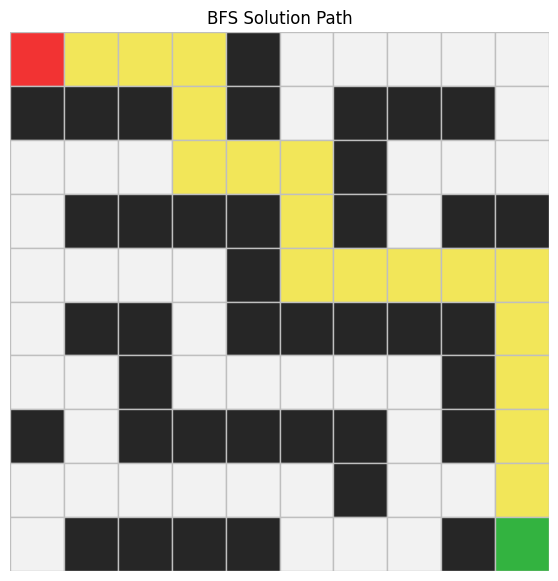

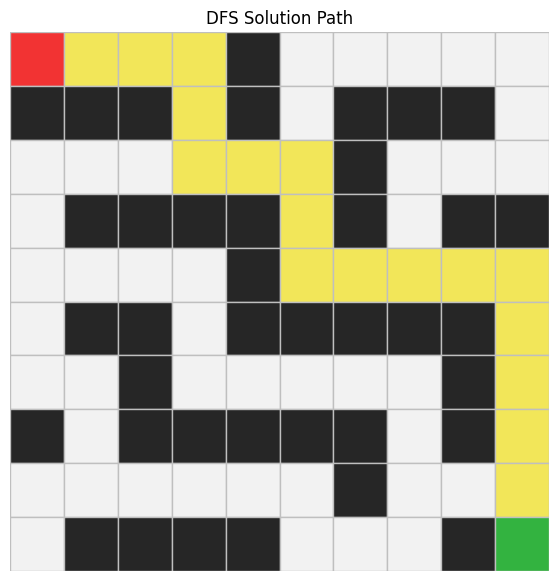

In [236]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [237]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
     
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,1,0,0,0,1,0],
    [0,1,0,1,1,1,0],
    [0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0],
    [0,0,0,0,0,0,0]

]

custom_start_1 = (1,1)
custom_goal_1 = (6,3)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,9.0,9.0,28,2,28
1,DFS,success,NaN,15.0,15.0,20,5,20
2,DLS,failure,20.0,NaN,NaN,1,1,0
3,IDS,failure,1.0,NaN,NaN,1,1,0


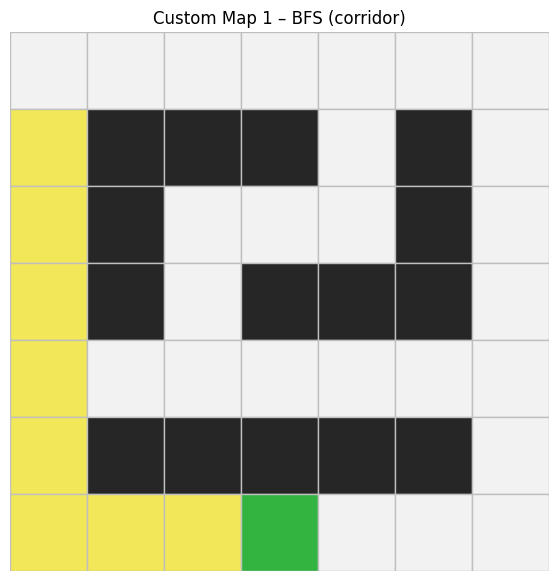

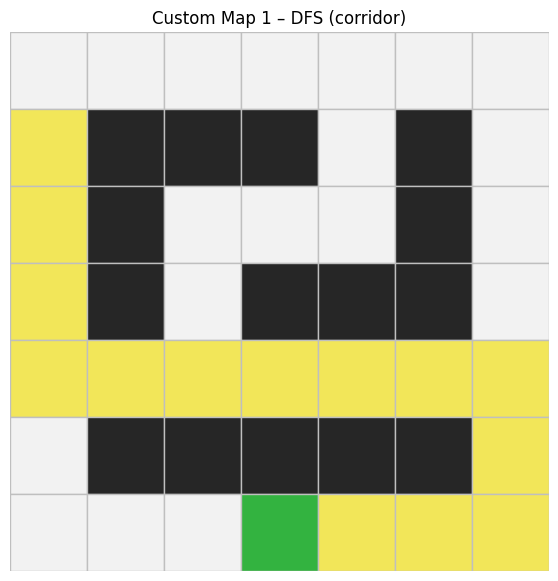

In [238]:
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[0].path,
          title="Custom Map 1 – BFS (corridor)")
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path,
          title="Custom Map 1 – DFS (corridor)")

In [239]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    
    [0,0,0,1,0,0,0,0],
    [0,1,0,1,0,1,1,0],
    [0,0,0,0,0,1,0,0],
    [0,1,1,1,0,1,0,1],
    [0,0,0,1,0,0,0,1],
    [0,1,0,1,1,1,0,0],
    [0,0,0,0,0,0,0,1],
    [0,1,1,1,1,1,0,0]

]

custom_start_2 = (0,0)
custom_goal_2 = (0,7)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,11.0,11.0,31,2,31
1,DFS,success,NaN,15.0,15.0,37,3,37
2,DLS,failure,20.0,NaN,NaN,1,1,0
3,IDS,failure,1.0,NaN,NaN,1,1,0


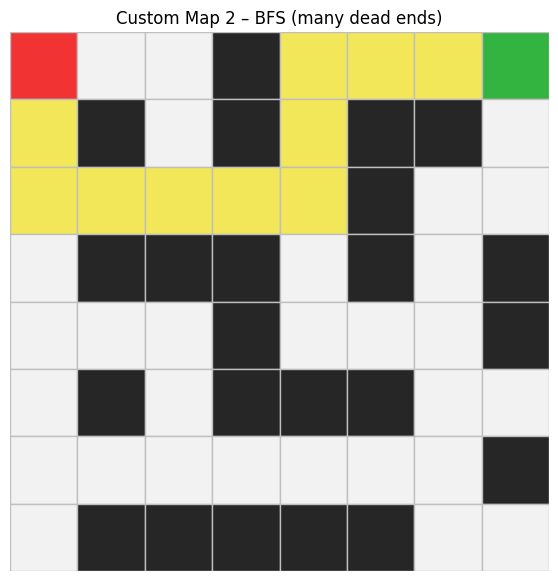

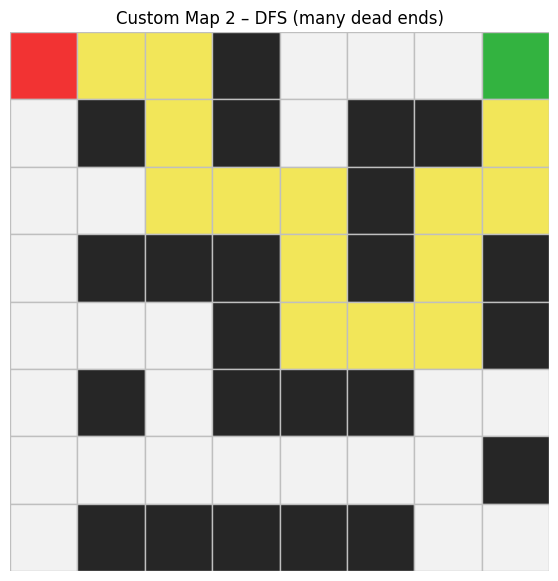

In [240]:
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[0].path,
          title="Custom Map 2 – BFS (many dead ends)")
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path,
          title="Custom Map 2 – DFS (many dead ends)")

## 15. Reflection Questions

### 15.1 Problem Formulation

1. **State:** A tuple (row, col) representing the drone's current grid position.
2. **Action:** A movement direction - UP, DOWN, LEFT, or RIGHT.
3. **result function:** Returns the new (row, col) state after applying a move.
4. **Separation principle:** Separating the problem from the algorithm means the same BFS/DFS/IDS code works unchanged on any Problem subclass. Any changes to the environment only touch GridProblem.

### 15.2 BFS

1. **FIFO queue:** Makes sure that nodes are expanded level by level. Every node at depth d is expanded before any node at depth d+1, which guarantees the shallowest goal is found first.
2. **Shortest path:** Because every step costs 1 and BFS expands depth before d+1, the first time BFS reaches the goal it has used the minimum number of steps, which equals the minimum cost on a unit-cost grid.
3. **`reached` set:** Prevents from expanding a state that was already reached via an equally-short or shorter path. Without it, BFS would loop in grids with cycles and re-add states to the frontier exponentially.

### 15.3 DFS

1. **Stack:** LIFO ordering always expands the most recently added (deepest) node, driving the search downward along one branch before backtracking.
2. **Optimality:** DFS is **not** guaranteed to find the shortest path. It commits to the first path it discovers, which may be arbitrarily longer than optimal.
3. **Memory advantage:** When the solution is deep and the tree is narrow, DFS only needs O(breadth * depth) memory (the current path plus siblings at each level), versus O(breadth ^ depth) for BFS.
4. **Bad cases:** DFS performs badly in infinite state spaces without cycle checking, in spaces where the goal is shallow but DFS dives into a deep subtree, and whenever the first complete path found is much longer than the optimal one.

### 15.4 DLS

1. **Limit too small:** Returns that the search hit the depth limit without finding the goal, but cannot rule out a solution existing deeper.
2. **`"cutoff"` meaning:** The search did not prove there is no solution. It just reached its exploration limit. A solution might still exist below the limit.
3. **DLS vs DFS:** DLS is DFS with a hard ceiling on depth. It avoids going down indefinitely but can also miss out on solutions which exist deeper.
4. **Path-cycle checking:** When there's no global reached set, DLS must at least avoid revisiting nodes on the current path to prevent having an infinite loop. A global set is not used because DLS relies on depth bounding, not state de-duplication.

### 15.5 IDS

1. **Increasing limits:** Each DLS call with a new limit extends the reachable frontier by one depth layer, eventually reaching any finite solution.
2. **Completeness:** Even if a small limit misses the goal, IDS keeps increasing the limit. For any finite solution depth d, the run with limit = d will find it — so IDS is complete.
3. **Memory:** Like DLS, each iteration uses only O(b·d) space; there is no global frontier accumulating all nodes.
4. **Re-expansion cost:** Nodes at depth k are expanded once in every iteration from limit k to the final limit. For a branching factor b, the overhead is a constant factor = b/(b−1) relative to BFS, which is negligible for b ≥ 2.

### 15.6 Real-World Drone Context

1. **Route quality:** Battery consumption (terrain difficulty), wind zones, legal no-fly zones, signal coverage, and collision risk all make some routes safer or cheaper than others beyond mere step count.
2. **Fewest moves:** **BFS** — it is guaranteed to find the goal closest to the initial node and is optimal on unit-cost grids.
3. **Limiting search depth:** **DLS** — it directly enforces a hard depth cap, preventing the drone from planning paths longer than a given number of moves.
4. **Grid model limitations:** The grid ignores continuous 3-D space, variable wind and weather, battery state, sensor coverage, multi-agent conflicts, and the fact that real drone motion is not confined to four cardinal directions.